In [62]:
pip install pandas numpy scikit-learn streamlit joblib

In [68]:
!pip install kagglehub

โหลด

In [75]:
import kagglehub

path = kagglehub.dataset_download("grouplens/movielens-20m-dataset")

print("Dataset path:", path)

Using Colab cache for faster access to the 'movielens-20m-dataset' dataset.
Dataset path: /kaggle/input/movielens-20m-dataset


dataset

In [80]:
import pandas as pd

ratings = pd.read_csv("/kaggle/input/movielens-20m-dataset/rating.csv", nrows=500000)
movies = pd.read_csv("/kaggle/input/movielens-20m-dataset/movie.csv")

print("ratings rows:", len(ratings))
print("movies rows:", len(movies))

data = pd.merge(ratings, movies, on="movieId")
data.head()

ratings rows: 500000
movies rows: 27278


,userId,movieId,rating,timestamp,title,genres
0,1,2,3.5,2005-04-02 23:53:47,Jumanji (1995),Adventure|Children|Fantasy
1,1,29,3.5,2005-04-02 23:31:16,"City of Lost Children, The (Cité des enfants p...",Adventure|Drama|Fantasy|Mystery|Sci-Fi
2,1,32,3.5,2005-04-02 23:33:39,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller
3,1,47,3.5,2005-04-02 23:32:07,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,3.5,2005-04-02 23:29:40,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


EDA (สำรวจข้อมูล)

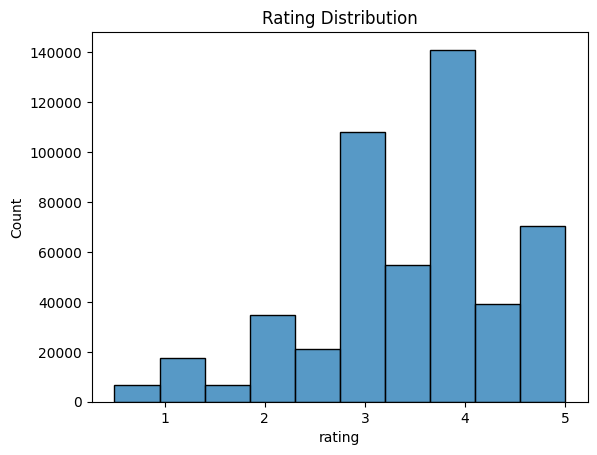

,rating
title,
First Position (2011),5.0
Straight to Hell (1987),5.0
Babylon 5,5.0
"Stooge, The (1953)",5.0
Storefront Hitchcock (1997),5.0
No End (Bez konca) (1985),5.0
"Indian Runner, The (1991)",5.0
"Chaperone, The (2011)",5.0
Wuthering Heights (1970),5.0


In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data["rating"], bins=10)
plt.title("Rating Distribution")
plt.show()

top_movies = data.groupby("title")["rating"].mean().sort_values(ascending=False)
top_movies.head(10)

Feature Engineering

In [85]:
movie_stats = data.groupby("movieId").agg({
    "rating":["mean","count"]
})

movie_stats.columns = ["avg_rating","num_rating"]
movie_stats = movie_stats.reset_index()

data = pd.merge(data, movie_stats, on="movieId")

data.head()

,userId,movieId,rating,timestamp,title,genres,avg_rating,num_rating
0,1,2,3.5,2005-04-02 23:53:47,Jumanji (1995),Adventure|Children|Fantasy,3.291139,553
1,1,29,3.5,2005-04-02 23:31:16,"City of Lost Children, The (Cité des enfants p...",Adventure|Drama|Fantasy|Mystery|Sci-Fi,3.940529,227
2,1,32,3.5,2005-04-02 23:33:39,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller,3.902204,1089
3,1,47,3.5,2005-04-02 23:32:07,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,4.088398,1086
4,1,50,3.5,2005-04-02 23:29:40,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,4.368309,1177


เตรียม Feature

In [86]:
X = data[["userId","movieId","avg_rating","num_rating"]]

y = data["rating"]

Train Test Split

In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

สร้างโมเดล

In [97]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [98]:
lr_model = LinearRegression()

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    random_state=42
)

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

Train

In [99]:
lr_model.fit(X_train, y_train)

rf_model.fit(X_train, y_train)

gb_model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [100]:
lr_pred = lr_model.predict(X_test)

rf_pred = rf_model.predict(X_test)

gb_pred = gb_model.predict(X_test)

Evaluation

In [102]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))

เปรียบเทียบผล

In [103]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        lr_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse,
        gb_rmse
    ]
})

results

,Model,MAE,RMSE
0,Linear Regression,0.717096,0.926801
1,Random Forest,0.695981,0.902647
2,Gradient Boosting,0.708381,0.915905


Visualization

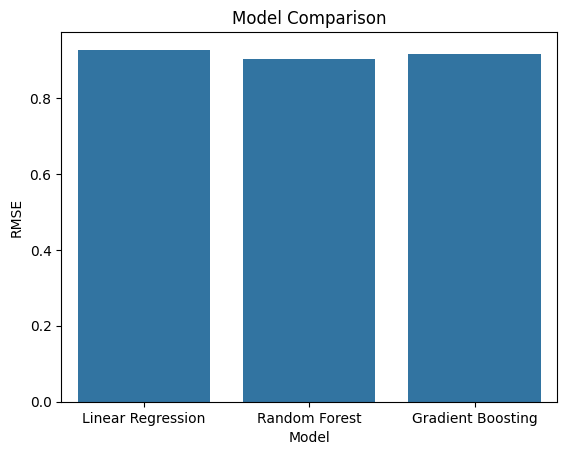

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="Model", y="RMSE", data=results)

plt.title("Model Comparison")
plt.show()

Save โมเดลที่ดีที่สุด

In [105]:
import joblib

joblib.dump(rf_model, "movie_recommendation_model.pkl")

['movie_recommendation_model.pkl']

In [106]:
results.to_csv("model_comparison.csv", index=False)

top10_movies

In [107]:
movies_unique = data.drop_duplicates("movieId")

X_pred = movies_unique[[
    "userId",
    "movieId",
    "avg_rating",
    "num_rating"
]].copy()

# สมมติ user = 1
X_pred["userId"] = 1

pred = rf_model.predict(X_pred)

movies_unique["pred_rating"] = pred

/tmp/ipykernel_406/861528715.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies_unique["pred_rating"] = pred


In [108]:
recommend = movies_unique.sort_values(
    "pred_rating",
    ascending=False
)

recommend[["title","genres","pred_rating"]].head(10)

,title,genres,pred_rating
53880,Sonic Outlaws (1995),Documentary,5.000
45830,"My Mother's Castle (Château de ma mère, Le) (1...",Comedy|Drama,5.000
497233,All About Lily Chou-Chou (Riri Shushu no subet...,Crime|Drama|Thriller,4.995
440010,"Internet's Own Boy: The Story of Aaron Swartz,...",Documentary,4.995
489358,Diana Vreeland: The Eye Has to Travel (2011),Documentary,4.995
233938,Innocent Voices (Voces inocentes) (2004),Drama|War,4.995
187671,"Dirty Carnival, A (Biyeolhan geori) (2006)",Action|Crime|Thriller,4.995
197510,We Are The Night (Wir sind die Nacht) (2010),Drama|Fantasy|Horror,4.995
444382,Little Men (1998),Drama,4.995
418044,Box of Moon Light (1996),Comedy|Drama,4.995


In [109]:
recommend.head(10)[["title","genres","pred_rating"]].to_csv(
    "top10_movies.csv",
    index=False
)